In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load Dataset CIFAR-10
print("Memuat dataset CIFAR-10...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalisasi nilai pixel agar berada di antara 0 dan 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Membangun Arsitektur CNN from Scratch
model_cnn = models.Sequential([
    # Convolution Layer 1 + Pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2 + Pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten layer
    layers.Flatten(),

    # Dense layer (Hidden Layer)
    layers.Dense(64, activation='relu'),

    # Output layer (10 kelas untuk CIFAR-10)
    layers.Dense(10, activation='softmax')
])

# 3. Compile Model
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 4. Training Model (Bisa disesuaikan jumlah epoch-nya)
print("Memulai proses training CNN...")
history_cnn = model_cnn.fit(x_train, y_train, epochs=10,
                            validation_data=(x_test, y_test))

print("Training selesai!")

Memuat dataset CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2794s 16us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Memulai proses training CNN...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 56ms/step - accuracy: 0.4525 - loss: 1.5042 - val_accuracy: 0.5582 - val_loss: 1.2238
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 51ms/step - accuracy: 0.6013 - loss: 1.1327 - val_accuracy: 0.5681 - val_loss: 1.2525
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6512 - loss: 0.9934 - val_accuracy: 0.6563 - val_loss: 0.9762
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6847 - loss: 0.8955 - val_accuracy: 0.6626 - val_loss: 0.9641
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7106 - loss: 0.8267 - val_accuracy: 0.6908 - val_loss: 0.8898
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7281 - loss: 0.7737 - val_accuracy: 0.7016 - val_loss: 0.8587
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.7457 - loss: 0.7255 - val_accuracy: 0.6948 - val_loss: 0.9017
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78

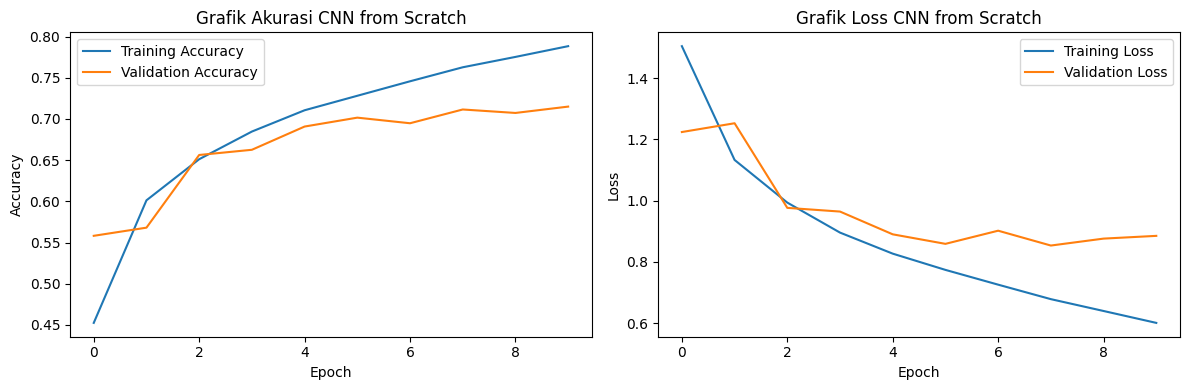

Menyiapkan Confusion Matrix...
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


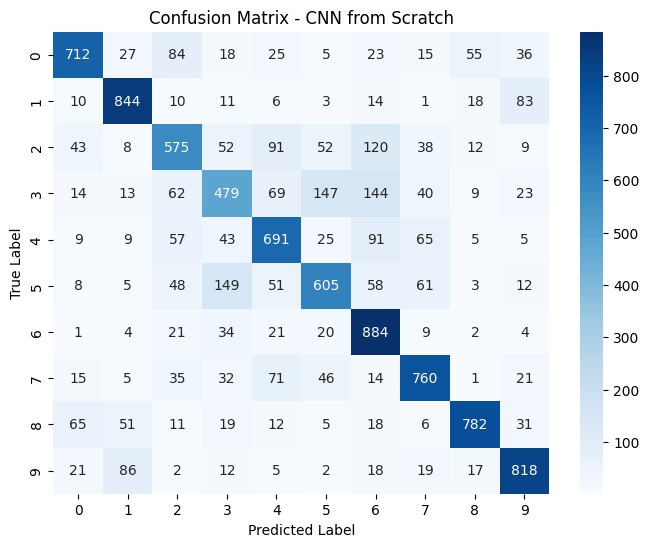

In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Visualisasi Grafik Akurasi dan Loss
plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi CNN from Scratch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss CNN from Scratch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Membuat Confusion Matrix
print("Menyiapkan Confusion Matrix...")
y_pred_cnn = model_cnn.predict(x_test)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_cnn = y_test.flatten()

cm_cnn = confusion_matrix(y_true_cnn, y_pred_classes_cnn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN from Scratch')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [10]:
import os
import urllib.request
import zipfile
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

print("1. Mengunduh dataset Cats vs Dogs...")
url = 'https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip'
zip_path = 'cats_and_dogs_filtered.zip'

# Download manual agar file jelas tersimpan di folder proyek lu
if not os.path.exists(zip_path):
    urllib.request.urlretrieve(url, zip_path)
    print("Download selesai!")
else:
    print("File zip sudah ada, lanjut ke ekstrak.")

print("2. Mengekstrak dataset...")
# Ekstrak di direktori saat ini (folder yang sama dengan notebook)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('.')
    print("Ekstrak selesai!")

# Path fix ke folder hasil ekstrak (pasti ada karena ada di folder proyek)
PATH = './cats_and_dogs_filtered'
train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

BATCH_SIZE = 32
IMG_SIZE = (150, 150)

print("3. Menyiapkan data training dan validation...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Layer untuk normalisasi pixel (0-255 menjadi 0-1)
rescale_layer = layers.Rescaling(1./255)

print("4. Membangun model Transfer Learning (MobileNetV2)...")
# Menggunakan MobileNetV2 sebagai base model (Feature Extraction)
base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Membekukan layer bawaan

# Membuat arsitektur baru
model_tl = models.Sequential([
    rescale_layer,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid') # 1 neuron pakai sigmoid untuk Kucing vs Anjing
])

# Compile model
model_tl.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("5. Memulai proses training Transfer Learning...")
history_tl = model_tl.fit(train_dataset, epochs=5, validation_data=validation_dataset)

print("Training Transfer Learning selesai! Mantap!")

1. Mengunduh dataset Cats vs Dogs...
Download selesai!
2. Mengekstrak dataset...
Ekstrak selesai!
3. Menyiapkan data training dan validation...
Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
4. Membangun model Transfer Learning (MobileNetV2)...


/tmp/ipykernel_670/2323185196.py:53: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5. Memulai proses training Transfer Learning...
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8995 - loss: 0.2415 - val_accuracy: 0.9440 - val_loss: 0.1376
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9610 - loss: 0.1152 - val_accuracy: 0.9440 - val_loss: 0.1285
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9655 - loss: 0.1001 - val_accuracy: 0.9540 - val_loss: 0.1159
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9695 - loss: 0.0899 - val_accuracy: 0.9520 - val_loss: 0.1177
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9740 - loss: 0.0805 - val_accuracy: 0.9550 - val_loss: 0.1123
Training Transfer Learning selesai! Mantap!


1. Menyiapkan Grafik Akurasi dan Loss...


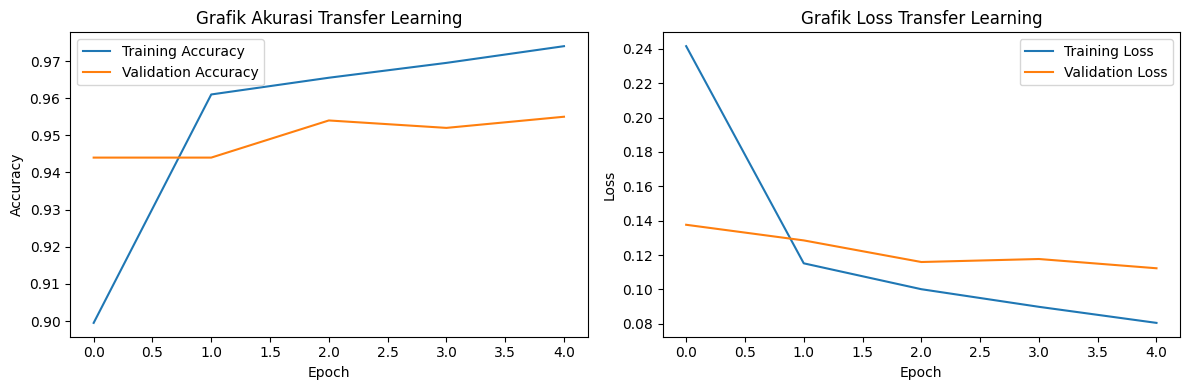

2. Menyiapkan Confusion Matrix Transfer Learning...


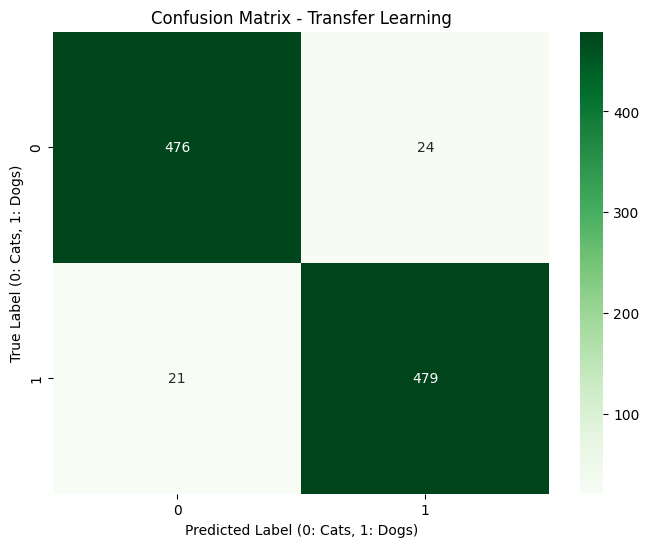

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("1. Menyiapkan Grafik Akurasi dan Loss...")
plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Training Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("2. Menyiapkan Confusion Matrix Transfer Learning...")
y_true_tl = []
y_pred_probs_tl = []

# Mengambil label asli dan hasil prediksi secara berurutan dari dataset validasi
for images, labels in validation_dataset:
    y_true_tl.extend(labels.numpy())
    preds = model_tl.predict(images, verbose=0)
    y_pred_probs_tl.extend(preds)

y_true_tl = np.array(y_true_tl)
y_pred_probs_tl = np.array(y_pred_probs_tl)

# Mengubah probabilitas menjadi kelas 0 atau 1 (Threshold 0.5)
y_pred_classes_tl = (y_pred_probs_tl > 0.5).astype(int).flatten()

# Membuat Confusion Matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_classes_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens') # Pakai warna hijau biar beda sama CNN
plt.title('Confusion Matrix - Transfer Learning')
plt.xlabel('Predicted Label (0: Cats, 1: Dogs)')
plt.ylabel('True Label (0: Cats, 1: Dogs)')
plt.show()

Mengambil contoh gambar untuk visualisasi prediksi...


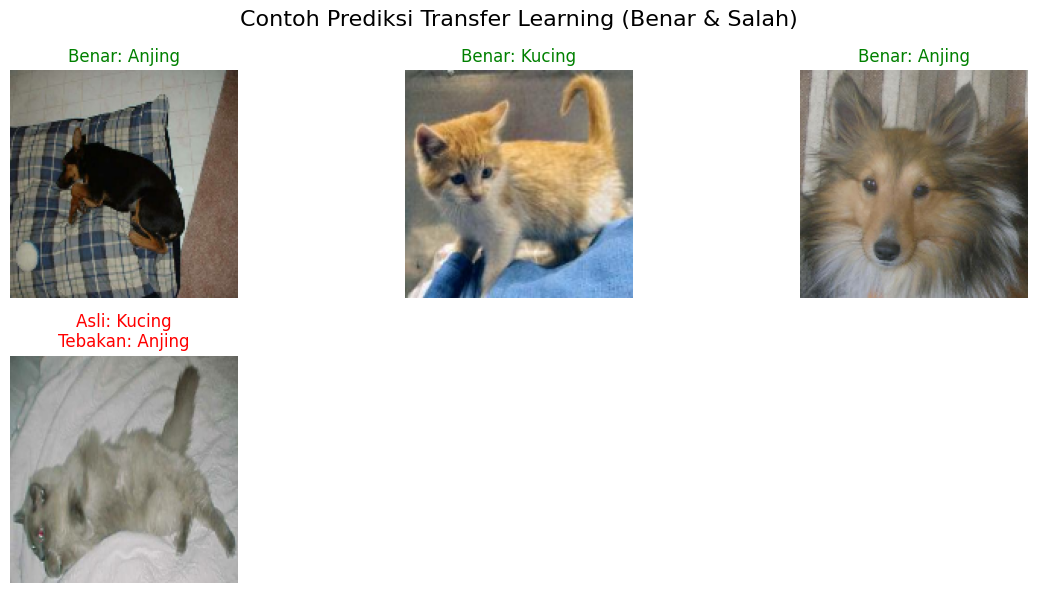

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

print("Mengambil contoh gambar untuk visualisasi prediksi...")
# Ambil 1 batch (32 gambar) dari data validasi
for images, labels in validation_dataset.take(1):
    # Lakukan prediksi pakai model Transfer Learning
    preds = model_tl.predict(images, verbose=0)
    pred_classes = (preds > 0.5).astype(int).flatten()
    true_classes = labels.numpy()
    break # Cukup ambil 1 batch aja

class_names = ['Kucing', 'Anjing']

# Pisahkan index gambar yang tebakannya benar dan salah
correct_indices = np.where(pred_classes == true_classes)[0]
incorrect_indices = np.where(pred_classes != true_classes)[0]

plt.figure(figsize=(12, 6))

# 1. Menampilkan 3 contoh prediksi BENAR
for i, idx in enumerate(correct_indices[:3]):
    plt.subplot(2, 3, i + 1)

    # FIX: Ubah format tensor TensorFlow ke format gambar standar (uint8)
    img_to_show = images[idx].numpy().astype("uint8")

    plt.imshow(img_to_show)
    plt.title(f"Benar: {class_names[true_classes[idx]]}", color='green')
    plt.axis('off')

# 2. Menampilkan contoh prediksi SALAH (maksimal 3)
num_incorrect = min(3, len(incorrect_indices))

if num_incorrect == 0:
    print("Wah, akurasi model lu lagi bagus banget di batch ini, gak ada yang salah tebak!")
else:
    for i in range(num_incorrect):
        idx = incorrect_indices[i]
        plt.subplot(2, 3, i + 4)

        # FIX: Ubah format tensor TensorFlow ke format gambar standar (uint8)
        img_to_show = images[idx].numpy().astype("uint8")

        plt.imshow(img_to_show)
        plt.title(f"Asli: {class_names[true_classes[idx]]}\nTebakan: {class_names[pred_classes[idx]]}", color='red')
        plt.axis('off')

plt.suptitle("Contoh Prediksi Transfer Learning (Benar & Salah)", fontsize=16)
plt.tight_layout()
plt.show()